In [15]:
import pyuff
import numpy as np

def load_uff_as_wav_format(uff_file_path):
    """
    Загружает UFF файл и преобразует в формат, понятный для основного кода
    Возвращает: fs (частота дискретизации), data (2 канала)
    """
    # Открываем UFF файл
    uff_file = pyuff.UFF(uff_file_path)
    
    # Получаем типы наборов
    set_types = uff_file.get_set_types()
    print(f"Типы наборов: {set_types}")
    
    # Читаем все наборы
    all_datasets = uff_file.read_sets()
    
    # Извлекаем данные
    frequencies = None
    ref_spectrum = None  # эталон
    cal_spectrum = None  # ПГД
    
    for i, dataset in enumerate(all_datasets):
        if isinstance(dataset, dict):
            # Частоты
            if 'x' in dataset:
                frequencies = dataset['x']
            
            # Данные
            if 'y' in dataset:
                data = dataset['y']
            elif 'data' in dataset:
                data = dataset['data']
            else:
                # Ищем первый массив numpy
                for key, value in dataset.items():
                    if isinstance(value, np.ndarray) and key != 'x':
                        data = value
                        break
            
            # Берем модуль если комплексные
            if np.iscomplexobj(data):
                data = np.abs(data)
            
            # Распределяем
            if i == 0:
                ref_spectrum = data
            elif i == 1:
                cal_spectrum = data
    
    if frequencies is None:
        raise ValueError("Не найдены частоты")
    
    # Приводим к 1D если нужно
    if ref_spectrum.ndim > 1:
        ref_spectrum = ref_spectrum[:, 0]
    if cal_spectrum.ndim > 1:
        cal_spectrum = cal_spectrum[:, 0]
    
    # Для совместимости с кодом, который ожидает временные ряды,
    # мы создадим "псевдо-временные" ряды, используя обратное преобразование
    # ИЛИ просто вернем спектры, а fs сделаем равной 2*max_freq
    
    max_freq = frequencies[-1]
    fs = 2 * max_freq  # Частота Найквиста
    
    # Создаем простой массив данных с 2 каналами
    # Для обратной совместимости с вашим кодом
    n_points = len(frequencies)
    
    # Создаем структуру данных как в WAV файле
    data = np.zeros((n_points, 2))
    data[:, 0] = ref_spectrum
    data[:, 1] = cal_spectrum
    
    print(f"\nЗагружено:")
    print(f"  Частот: {n_points}")
    print(f"  Диапазон: {frequencies[0]:.2f} - {frequencies[-1]:.2f} Гц")
    print(f"  Эквивалентная fs: {fs:.1f} Гц")
    
    return fs, data, frequencies

# # ИСПОЛЬЗОВАНИЕ:
# # Загружаем данные
# fs, data, freqs = load_uff_as_wav_format('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-2.uff')

# # Теперь data готова для передачи в ваш код:
# # micr = data[:, 0] - np.mean(data[:, 0])
# # pgd = data[:, 1] - np.mean(data[:, 1])

# # Проверка
# print(f"\nФорма данных: {data.shape}")
# print(f"Канал 0 (эталон): первые 5 значений = {data[:5, 0]}")
# print(f"Канал 1 (ПГД): первые 5 значений = {data[:5, 1]}")

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter, LogLocator
import matplotlib.ticker as ticker

def calibrate_from_ambient_noise(data, fs, segment_duration=60, plot=True):
    
    micr = data[:, 0] - np.mean(data[:, 0])
    pgd = data[:, 1] - np.mean(data[:, 1])
    
    # 2. Параметры обработки
    seg_samples = int(segment_duration * fs)
    n_segments = len(micr) // seg_samples
    
    print(f"FS: {fs} Гц, Длительность: {len(micr)/fs/3600:.1f} ч, Сегментов: {n_segments}")
    
    # 3. Расчет 1/12 октавных частот
    micr_freq = 1000.0
    n_min = int(12 * np.log2(1 / micr_freq))
    n_max = int(12 * np.log2((fs/2) / micr_freq))
    f_centers = micr_freq * (2 ** (np.arange(n_min, n_max + 1) / 12))
    
    # 4. Подготовка масок для фильтрации
    nfft = seg_samples 
    freqs = np.fft.rfftfreq(nfft, 1/fs)
    
    filters = []
    valid_freqs = []
    for fc in f_centers:
        f_low = fc / 2**(1/24)
        f_high = fc * 2**(1/24)
        mask = (freqs >= f_low) & (freqs < f_high)
        if np.any(mask):
            filters.append(mask)
            valid_freqs.append(fc)
    
    n_bands = len(filters)
    print(f"1/12 октавных полос: {n_bands} ({valid_freqs[0]:.2f} - {valid_freqs[-1]:.1f} Гц)")
    
    # 5. Накопление спектров
    micr_power_sum = np.zeros(n_bands)
    pgd_power_sum = np.zeros(n_bands)
    valid_segments = 0
    
    for i in tqdm(range(n_segments), desc="Обработка"):
        start = i * seg_samples
        micr_seg = micr[start:start + seg_samples]
        pgd_seg = pgd[start:start + seg_samples]
        
        micr_fft = np.fft.rfft(micr_seg)
        pgd_fft = np.fft.rfft(pgd_seg)
        
        # Спектр мощности
        micr_power = np.abs(micr_fft)**2 / seg_samples
        pgd_power = np.abs(pgd_fft)**2 / seg_samples
        
        # Усреднение по октавным полосам
        for j, mask in enumerate(filters):
            if np.any(mask):
                micr_power_sum[j] += np.mean(micr_power[mask])
                pgd_power_sum[j] += np.mean(pgd_power[mask])
        
        valid_segments += 1
    
    print(f"Валидных сегментов: {valid_segments}/{n_segments}")
    
    # 6. Усреднение
    micr_power_avg = micr_power_sum / valid_segments
    pgd_power_avg = pgd_power_sum / valid_segments
    
    micr_mc2 = 10 * np.log10(micr_power_avg / micr_power_avg[0])
    pgd_volt = 10 * np.log10(pgd_power_avg / pgd_power_avg[0])
    sensitivity = (micr_power_avg / pgd_power_avg)
    

    if plot:
        # Функция для форматирования подписей частот
        def freq_formatter(x, pos):
            if x < 0.1:
                return f'{x:.3f}'
            elif x < 1:
                return f'{x:.2f}'
            elif x < 10:
                return f'{x:.1f}'
            else:
                return f'{x:.0f}'
        
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))
        
        # Создаем массив логарифмических подписей: 0.2, 0.4, 0.6, 0.8, 2, 4, 6, 8, 20, 40, 60, 80, 200 и т.д.
        def get_log_ticks(min_freq, max_freq):
            ticks = []
            # Базовые значения
            bases = [1, 2, 4, 6, 8]
            
            # Определяем начальный порядок
            start_order = int(np.floor(np.log10(min_freq)))
            end_order = int(np.ceil(np.log10(max_freq)))
            
            for order in range(start_order - 1, end_order + 1):
                for base in bases:
                    tick = base * (10 ** order)
                    if min_freq <= tick <= max_freq:
                        ticks.append(tick)
            
            if min_freq < 1:
                for base in [0.2, 0.4, 0.6, 0.8]:
                    if min_freq <= base <= max_freq:
                        ticks.append(base)
            
            return sorted(set(ticks))  # Убираем дубликаты и сортируем
        
      
        freq_ticks = get_log_ticks(valid_freqs[0], valid_freqs[-1])
        
        # Настройка первого графика
        ax1.semilogx(valid_freqs, micr_mc2, 'b-', linewidth=2)
        ax1.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
        
        # Устанавливаем пользовательские подписи
        ax1.set_xticks(freq_ticks)
        ax1.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], rotation=45, ha='right', fontsize=9)
        
        # Настройка сетки
        ax1.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
        
        ax1.set_xlabel('Частота (Гц)', fontsize=12)
        ax1.set_ylabel('Сейсмометр, дБ', fontsize=12)
        ax1.set_title('Эталон - сейсмометр', fontsize=14)
        ax1.set_xlim([valid_freqs[0], valid_freqs[-1]])
        ax1.tick_params(axis='both', which='major', labelsize=10)
        
        # Настройка второго графика
        ax2.semilogx(valid_freqs, pgd_volt, 'r-', linewidth=2)
        ax2.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
        
        ax2.set_xticks(freq_ticks)
        ax2.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], rotation=45, ha='right', fontsize=9)
        ax2.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
        
        ax2.set_xlabel('Частота (Гц)', fontsize=12)
        ax2.set_ylabel('Амплитуда, дБ', fontsize=12)
        ax2.set_title('Функция ПГД', fontsize=14)
        ax2.set_xlim([valid_freqs[0], valid_freqs[-1]])
        ax2.tick_params(axis='both', which='major', labelsize=10)
        
        # Настройка третьего графика
        ax3.semilogx(valid_freqs, pgd_power_avg, 'g-', linewidth=2)

        ax3.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
        
        ax3.set_xticks(freq_ticks)
        ax3.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], rotation=45, ha='right', fontsize=9)
        ax3.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
        
        ax3.set_xlabel('Частота (Гц)', fontsize=12)
        ax3.set_ylabel('Чувствительность, дБ', fontsize=12)
        ax3.set_title('График чувствительности', fontsize=14)
        ax3.set_xlim([valid_freqs[0], valid_freqs[-1]])
        ax3.tick_params(axis='both', which='major', labelsize=10)
        #ax3.set_xlim([20, 1000])  # X от 20 Гц до 20 кГц
        #ax3.set_ylim([-1, 3])
        
        plt.tight_layout()
        plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
        plt.show()
    
    return np.array(valid_freqs), micr_mc2, sensitivity


# if __name__ == "__main__":
#     freqs, cal_db, sens = calibrate_from_ambient_noise('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-1.wav', segment_duration=60)

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_55441/2479825943.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(wav_file)


FS: 8192 Гц, Длительность: 3.0 ч, Сегментов: 181
1/12 октавных полос: 144 (1.03 - 4000.0 Гц)


Обработка: 100%|██████████| 181/181 [00:02<00:00, 67.32it/s]


Валидных сегментов: 181/181


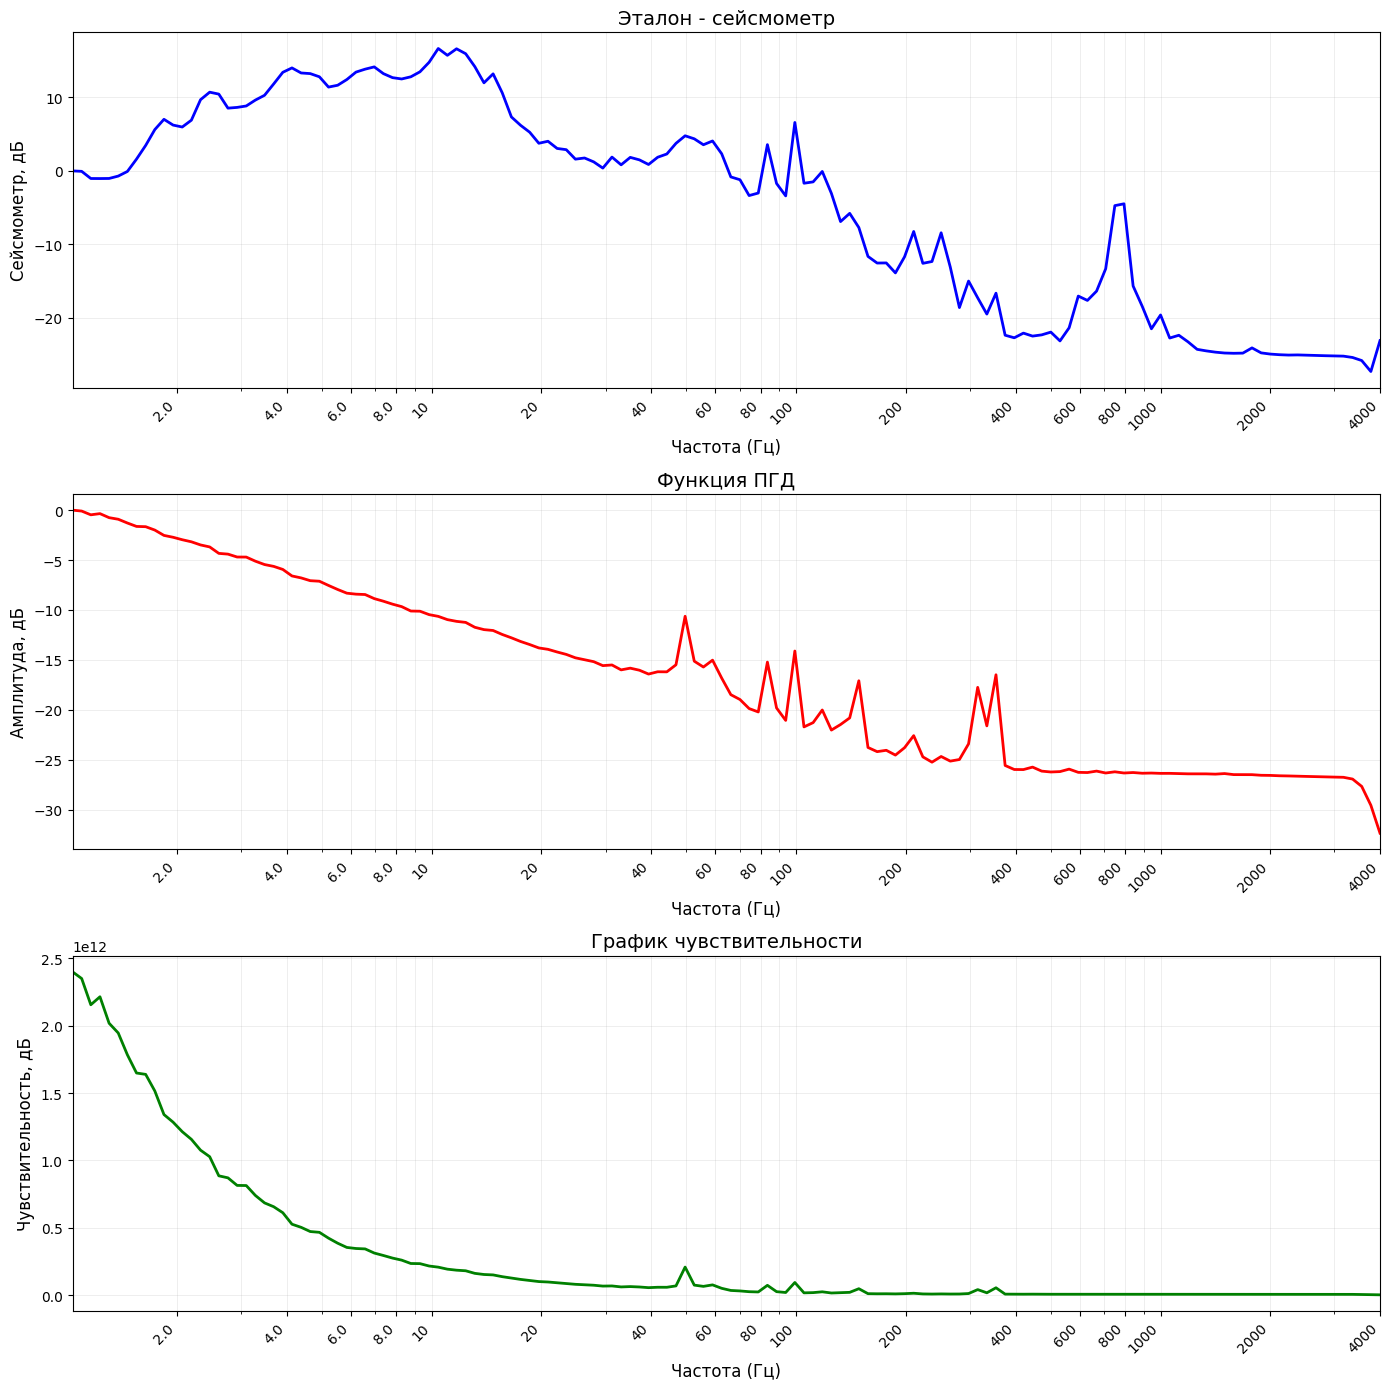

In [17]:
wav_file = '/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-022134(UTC)-Default setup-0058440553.wav'

fs, data = wavfile.read(wav_file)

if __name__ == "__main__":
    freqs, cal_db, sens = calibrate_from_ambient_noise(data, fs, segment_duration=60)


In [18]:
# fs_uff, data_uff, freqs_uff = load_uff_as_wav_format('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/Recording-2.uff')

# if __name__ == "__main__":
#     freqs, cal_db, sens = calibrate_from_ambient_noise(data_uff, fs, segment_duration=12)

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_55441/783773253.py:192: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-022134(UTC)-Default setup-0058440553.wav')


FS: 8192 Гц, Длительность: 3.0 ч, Сегментов: 181
1/12 октавных полос: 144 (1.03 - 4000.0 Гц)


Обработка: 100%|██████████| 181/181 [00:02<00:00, 63.90it/s]


Валидных сегментов: 181/181


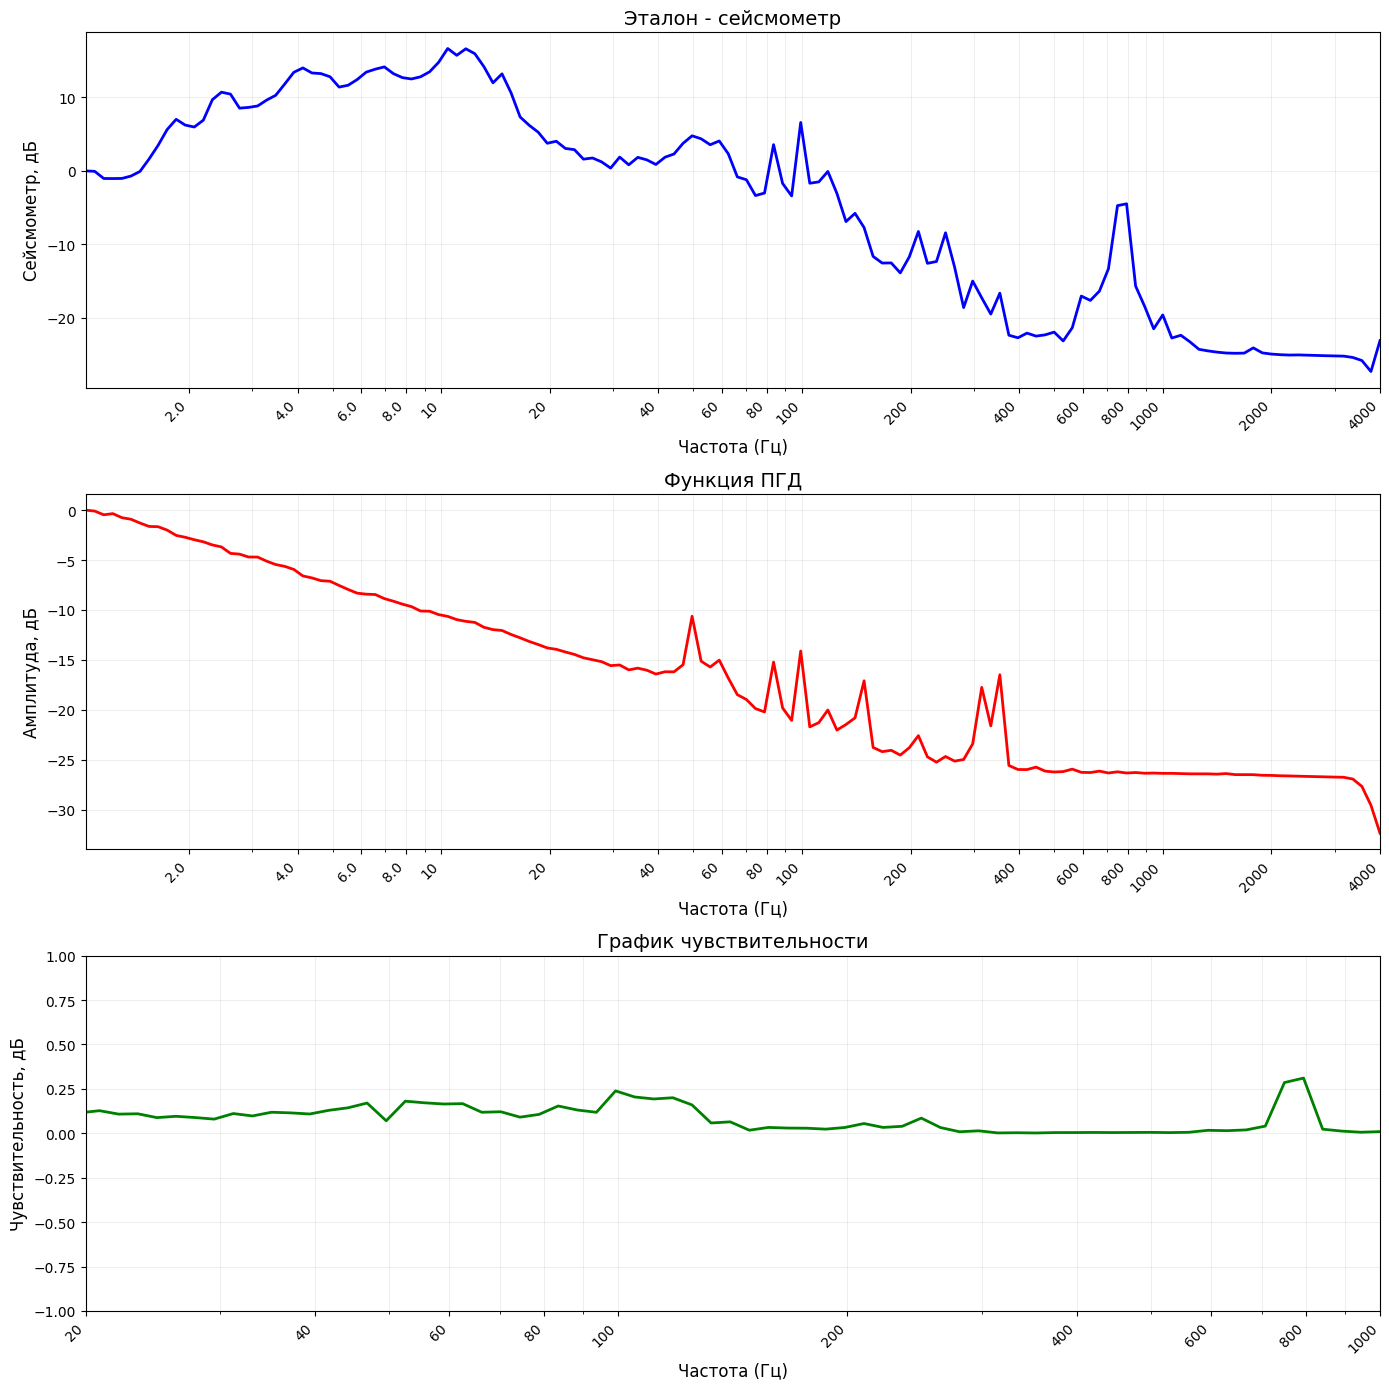

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter, LogLocator
import matplotlib.ticker as ticker

def plot_calibration_results(valid_freqs, micr_mc2, pgd_volt, sensitivity):
    """
    Функция для построения графиков калибровки
    
    Parameters:
    -----------
    valid_freqs : array
        Массив частот
    micr_mc2 : array
        Данные сейсмометра в дБ
    pgd_volt : array
        Данные ПГД в дБ
    sensitivity : array
        Данные чувствительности
    """
    
    # Функция для форматирования подписей частот
    def freq_formatter(x, pos):
        if x < 0.1:
            return f'{x:.3f}'
        elif x < 1:
            return f'{x:.2f}'
        elif x < 10:
            return f'{x:.1f}'
        else:
            return f'{x:.0f}'
    
    # Функция для создания логарифмических подписей
    def get_log_ticks(min_freq, max_freq):
        ticks = []
        bases = [1, 2, 4, 6, 8]
        
        start_order = int(np.floor(np.log10(min_freq)))
        end_order = int(np.ceil(np.log10(max_freq)))
        
        for order in range(start_order - 1, end_order + 1):
            for base in bases:
                tick = base * (10 ** order)
                if min_freq <= tick <= max_freq:
                    ticks.append(tick)
        
        if min_freq < 1:
            for base in [0.2, 0.4, 0.6, 0.8]:
                if min_freq <= base <= max_freq:
                    ticks.append(base)
        
        return sorted(set(ticks))
    
    # Создание фигуры с тремя подграфиками
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 14))
    
    # Получаем метки для осей X
    freq_ticks = get_log_ticks(valid_freqs[0], valid_freqs[-1])
    
    # График 1: Сейсмометр
    ax1.semilogx(valid_freqs, micr_mc2, 'b-', linewidth=2)
    ax1.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
    
    ax1.set_xticks(freq_ticks)
    ax1.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], 
                        rotation=45, ha='right', fontsize=9)
    ax1.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    
    ax1.set_xlabel('Частота (Гц)', fontsize=12)
    ax1.set_ylabel('Сейсмометр, дБ', fontsize=12)
    ax1.set_title('Эталон - сейсмометр', fontsize=14)
    ax1.set_xlim([valid_freqs[0], valid_freqs[-1]])
    ax1.tick_params(axis='both', which='major', labelsize=10)
    
    # График 2: ПГД
    ax2.semilogx(valid_freqs, pgd_volt, 'r-', linewidth=2)
    ax2.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
    
    ax2.set_xticks(freq_ticks)
    ax2.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], 
                        rotation=45, ha='right', fontsize=9)
    ax2.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    
    ax2.set_xlabel('Частота (Гц)', fontsize=12)
    ax2.set_ylabel('Амплитуда, дБ', fontsize=12)
    ax2.set_title('Функция ПГД', fontsize=14)
    ax2.set_xlim([valid_freqs[0], valid_freqs[-1]])
    ax2.tick_params(axis='both', which='major', labelsize=10)
    
    # График 3: Чувствительность
    ax3.semilogx(valid_freqs, sensitivity, 'g-', linewidth=2)
    ax3.grid(True, alpha=0.3, which='both', linestyle='-', linewidth=0.5)
    
    ax3.set_xticks(freq_ticks)
    ax3.set_xticklabels([freq_formatter(tick, None) for tick in freq_ticks], 
                        rotation=45, ha='right', fontsize=9)
    ax3.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
    
    ax3.set_xlabel('Частота (Гц)', fontsize=12)
    ax3.set_ylabel('Чувствительность, дБ', fontsize=12)
    ax3.set_title('График чувствительности', fontsize=14)
    ax3.set_xlim([20, 1000])  # Ограничение по X от 20 Гц до 1000 Гц
    ax3.set_ylim([-1, 1])      # Ограничение по Y от -1 до 1 дБ
    ax3.tick_params(axis='both', which='major', labelsize=10)
    
    plt.tight_layout()
    plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
    plt.show()


def calibrate_from_ambient_noise(data, fs, segment_duration=60, plot=True):
    
    micr = data[:, 0] - np.mean(data[:, 0])
    pgd = data[:, 1] - np.mean(data[:, 1])
    
    # 2. Параметры обработки
    seg_samples = int(segment_duration * fs)
    n_segments = len(micr) // seg_samples
    
    print(f"FS: {fs} Гц, Длительность: {len(micr)/fs/3600:.1f} ч, Сегментов: {n_segments}")
    
    # 3. Расчет 1/12 октавных частот
    micr_freq = 1000.0
    n_min = int(12 * np.log2(1 / micr_freq))
    n_max = int(12 * np.log2((fs/2) / micr_freq))
    f_centers = micr_freq * (2 ** (np.arange(n_min, n_max + 1) / 12))
    
    # 4. Подготовка масок для фильтрации
    nfft = seg_samples 
    freqs = np.fft.rfftfreq(nfft, 1/fs)
    
    filters = []
    valid_freqs = []
    for fc in f_centers:
        f_low = fc / 2**(1/24)
        f_high = fc * 2**(1/24)
        mask = (freqs >= f_low) & (freqs < f_high)
        if np.any(mask):
            filters.append(mask)
            valid_freqs.append(fc)
    
    n_bands = len(filters)
    print(f"1/12 октавных полос: {n_bands} ({valid_freqs[0]:.2f} - {valid_freqs[-1]:.1f} Гц)")
    
    # 5. Накопление спектров
    micr_power_sum = np.zeros(n_bands)
    pgd_power_sum = np.zeros(n_bands)
    valid_segments = 0
    
    for i in tqdm(range(n_segments), desc="Обработка"):
        start = i * seg_samples
        micr_seg = micr[start:start + seg_samples]
        pgd_seg = pgd[start:start + seg_samples]
        
        micr_fft = np.fft.rfft(micr_seg)
        pgd_fft = np.fft.rfft(pgd_seg)
        
        # Спектр мощности
        micr_power = np.abs(micr_fft)**2 / seg_samples
        pgd_power = np.abs(pgd_fft)**2 / seg_samples
        
        # Усреднение по октавным полосам
        for j, mask in enumerate(filters):
            if np.any(mask):
                micr_power_sum[j] += np.mean(micr_power[mask])
                pgd_power_sum[j] += np.mean(pgd_power[mask])
        
        valid_segments += 1
    
    print(f"Валидных сегментов: {valid_segments}/{n_segments}")
    
    # 6. Усреднение
    micr_power_avg = micr_power_sum / valid_segments
    pgd_power_avg = pgd_power_sum / valid_segments
    
    micr_mc2 = 10 * np.log10(micr_power_avg / micr_power_avg[0])
    pgd_volt = 10 * np.log10(pgd_power_avg / pgd_power_avg[0])
    sensitivity = (micr_power_avg / pgd_power_avg)
    
    # Построение графиков через отдельную функцию
    if plot:
        plot_calibration_results(valid_freqs, micr_mc2, pgd_volt, sensitivity)
    
    return np.array(valid_freqs), micr_mc2, sensitivity


# Пример использования
if __name__ == "__main__":
    # Загрузка данных из WAV файла
    fs, data = wavfile.read('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-022134(UTC)-Default setup-0058440553.wav')
    freqs, cal_db, sens = calibrate_from_ambient_noise(data, fs, segment_duration=60)

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_55441/3452512945.py:25: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(file_path)


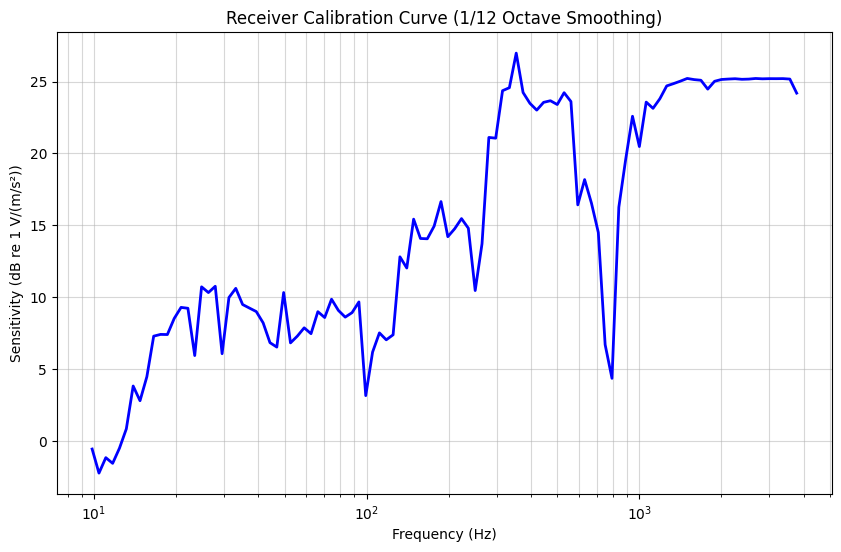

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch

def get_fractional_octave_bands(f_min, f_max, fraction=3):
    """Генерация граничных частот для дробно-октавных фильтров."""
    # Опорная частота по стандарту ISO 266
    f_ref = 1000.0
    
    # Расчет индексов полос
    n_min = np.floor(fraction * np.log2(f_min / f_ref))
    n_max = np.ceil(fraction * np.log2(f_max / f_ref))
    n = np.arange(n_min, n_max + 1)
    
    # Центральные и граничные частоты
    f_center = f_ref * (2 ** (n / fraction))
    f_lower = f_center * (2 ** (-1 / (2 * fraction)))
    f_upper = f_center * (2 ** (1 / (2 * fraction)))
    
    return f_lower, f_center, f_upper

def calibrate_receiver(file_path, duration_min=1):
    # 1. Загрузка данных
    fs, data = wavfile.read(file_path)
    # Нормализация, если файл 16-bit (зависит от АЦП)
    if data.dtype == np.int16:
        data = data / 32768.0
        
    ch_ref = data[:, 0]  # Эталон (m/s2)
    ch_rec = data[:, 1]  # Приемник (V)
    
    samples_per_seg = int(fs * duration_min * 60)
    num_segments = len(data) // samples_per_seg
    
    # Параметры октавных полос (например, от 10 Гц до 20 кГц)
    f_low, f_mid, f_high = get_fractional_octave_bands(10, fs/2.2, fraction=12)
    
    psd_ref_avg = []
    psd_rec_avg = []

    # 2. Обработка сегментов
    for i in range(num_segments):
        start = i * samples_per_seg
        end = start + samples_per_seg
        
        # Считаем спектральную плотность мощности (PSD)
        # nperseg выбираем так, чтобы разрешение было ~1/60 Гц (fs * 60)
        f, p_ref = welch(ch_ref[start:end], fs, nperseg=fs*60, window='hann')
        _, p_rec = welch(ch_rec[start:end], fs, nperseg=fs*60, window='hann')
        
        # 3. Интегрирование в 1/12 октавных полосах
        band_energy_ref = []
        band_energy_rec = []
        
        for fl, fh in zip(f_low, f_high):
            mask = (f >= fl) & (f < fh)
            band_energy_ref.append(np.trapz(p_ref[mask], f[mask]))
            band_energy_rec.append(np.trapz(p_rec[mask], f[mask]))
            
        psd_ref_avg.append(band_energy_ref)
        psd_rec_avg.append(band_energy_rec)

    # 4. Усреднение по всем минутам
    mean_ref = np.sqrt(np.mean(psd_ref_avg, axis=0)) # RMS в полосе
    mean_rec = np.sqrt(np.mean(psd_rec_avg, axis=0)) # RMS в полосе
    
    # 5. Расчет чувствительности в дБ
    # Чувствительность S = V / (m/s2)
    sensitivity = 20 * np.log10(mean_rec / mean_ref)
    
    return f_mid, sensitivity

# Визуализация результатов
freqs, sens_db = calibrate_receiver('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-082526(UTC)-Default setup-0080272085.wav')

plt.figure(figsize=(10, 6))
plt.semilogx(freqs, sens_db, label='Sensitivity Curve', color='blue', linewidth=2)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Sensitivity (dB re 1 V/(m/s²))')
plt.title('Receiver Calibration Curve (1/12 Octave Smoothing)')
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch

def get_octave_bands(f_min, f_max, fraction=3):
    """Генерация частотных полос для 1/12 октавы."""
    f_ref = 1000.0  # Стандартная опорная частота
    n_min = np.floor(fraction * np.log2(f_min / f_ref))
    n_max = np.ceil(fraction * np.log2(f_max / f_ref))
    n = np.arange(n_min, n_max + 1)
    
    f_center = f_ref * (2 ** (n / fraction))
    # Границы полос
    f_lower = f_center * (2 ** (-1 / (2 * fraction)))
    f_upper = f_center * (2 ** (1 / (2 * fraction)))
    
    return f_lower, f_center, f_upper

def calculate_sensitivity(file_path, duration_min=1):
    # 1. Чтение файла
    fs, data = wavfile.read(file_path)
    
    # Если файл в целочисленном формате, приводим к float
    # ВАЖНО: предполагаем, что шкала WAV уже соответствует физическим единицам
    if data.dtype == np.int16:
        data = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float64) / 2147483648.0

    ref_accel = data[:, 0]  # Канал 1: Эталон [м/с^2]
    rec_volts = data[:, 1]  # Канал 2: Приемник [В]

    samples_per_min = int(fs * 60 * duration_min)
    num_segments = len(data) // samples_per_min
    
    # Частотный диапазон (можно настроить под ваши задачи)
    f_low, f_mid, f_high = get_octave_bands(10, fs/2.5, fraction=12)
    
    # Массивы для накопления мощностей по сегментам
    total_p_ref = np.zeros(len(f_mid))
    total_p_rec = np.zeros(len(f_mid))

    # 2. Посегментная обработка (по 1 минуте)
    for i in range(num_segments):
        start = i * samples_per_min
        end = start + samples_per_min
        
        # Считаем PSD. nperseg=fs*60 дает разрешение 1/60 Гц
        f, p_ref = welch(ref_accel[start:end], fs, nperseg=fs*60, window='hann')
        _, p_rec = welch(rec_volts[start:end], fs, nperseg=fs*60, window='hann')
        
        # Интегрируем мощность в полосах 1/12 октавы
        for j in range(len(f_mid)):
            mask = (f >= f_low[j]) & (f < f_high[j])
            if np.any(mask):
                # Суммируем спектральную плотность мощности в полосе
                total_p_ref[j] += np.trapz(p_ref[mask], f[mask])
                total_p_rec[j] += np.trapz(p_rec[mask], f[mask])

    # 3. Усреднение и переход к среднеквадратичным значениям (RMS)
    rms_ref = np.sqrt(total_p_ref / num_segments)
    rms_rec = np.sqrt(total_p_rec / num_segments)
    

    
    # 4. Расчет чувствительности [В / (м/с^2)]
    # Чтобы избежать деления на ноль в пустых полосах
    sensitivity = np.divide(rms_rec, rms_ref, out=np.zeros_like(rms_rec), where=rms_ref!=0)
    
    return f_mid, sensitivity

# --- Запуск и визуализация ---
# Замените 'data.wav' на ваше имя файла
try:
    freqs, sens_linear = calculate_sensitivity('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-082526(UTC)-Default setup-0080272085.wav')

    plt.figure(figsize=(11, 6))
    plt.semilogx(freqs, sens_linear, 'b-o', markersize=4, label='Коэффициент преобразования')
    
    plt.grid(True, which="both", ls="--", alpha=0.7)
    plt.xlabel('Частота (Гц)', fontsize=12)
    plt.ylabel('Чувствительность [В / (м/с²)]', fontsize=12)
    plt.title('График чувствительности приемника (1/12 октавное усреднение)', fontsize=13)
    plt.legend()
    
    # Добавим подписи на основных октавных частотах для удобства
    plt.xticks([31.5, 63, 125, 250, 500, 1000, 2000, 4000, 8000], 
               ['31.5', '63', '125', '250', '500', '1k', '2k', '4k', '8k'])
    
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Файл не найден. Пожалуйста, проверьте путь к .wav файлу.")

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_55441/2101549000.py:22: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(file_path)


KeyboardInterrupt: 

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_55441/3642298764.py:18: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(file_path)


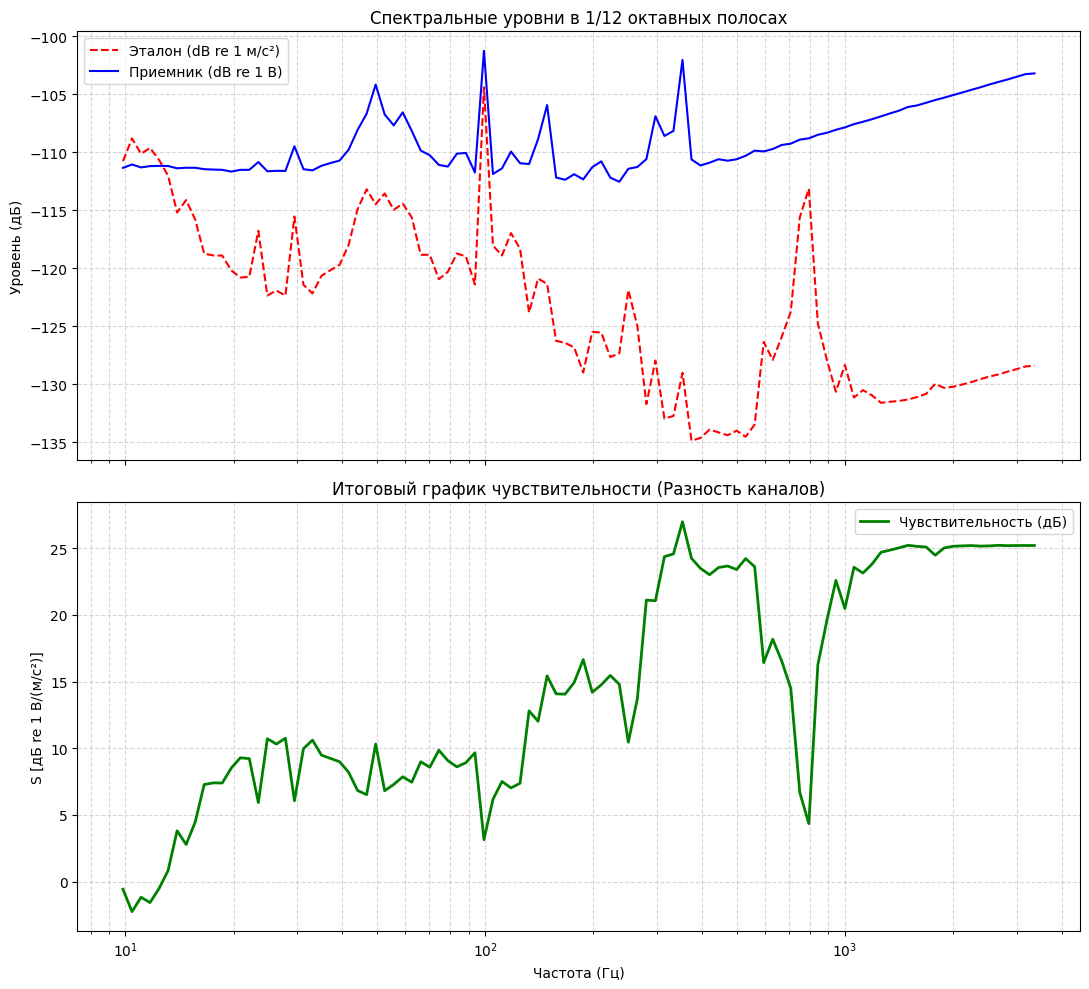

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch

def get_octave_bands(f_min, f_max, fraction=12):
    f_ref = 1000.0
    n_min = np.floor(fraction * np.log2(f_min / f_ref))
    n_max = np.ceil(fraction * np.log2(f_max / f_ref))
    n = np.arange(n_min, n_max + 1)
    
    f_center = f_ref * (2 ** (n / fraction))
    f_lower = f_center * (2 ** (-1 / (2 * fraction)))
    f_upper = f_center * (2 ** (1 / (2 * fraction)))
    return f_lower, f_center, f_upper

def calibrate_with_db(file_path, duration_min=1):
    fs, data = wavfile.read(file_path)
    
    # Приведение к float
    if data.dtype == np.int16:
        data = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float64) / 2147483648.0

    ref_accel = data[:, 0]  # [м/с^2]
    rec_volts = data[:, 1]  # [В]

    samples_per_min = int(fs * 60 * duration_min)
    num_segments = len(data) // samples_per_min
    
    f_low, f_mid, f_high = get_octave_bands(10, fs/2.5, fraction=12)
    
    # Накопители для мощности
    total_p_ref = np.zeros(len(f_mid))
    total_p_rec = np.zeros(len(f_mid))

    for i in range(num_segments):
        start = i * samples_per_min
        end = start + samples_per_min
        
        # Разрешение 1/60 Гц за счет nperseg=fs*60
        f, p_ref = welch(ref_accel[start:end], fs, nperseg=fs*60, window='hann')
        _, p_rec = welch(rec_volts[start:end], fs, nperseg=fs*60, window='hann')
        
        for j in range(len(f_mid)):
            mask = (f >= f_low[j]) & (f < f_high[j])
            if np.any(mask):
                total_p_ref[j] += np.trapz(p_ref[mask], f[mask])
                total_p_rec[j] += np.trapz(p_rec[mask], f[mask])

    # Среднеквадратичные значения (усреднение по времени)
    rms_ref = np.sqrt(total_p_ref / num_segments)
    rms_rec = np.sqrt(total_p_rec / num_segments)
    
    # Перевод в децибелы (уровни)
    # Используем 1e-12 как предохранитель от log(0)
    L_ref = 20 * np.log10(rms_ref + 1e-12) 
    L_rec = 20 * np.log10(rms_rec + 1e-12)
    
    # Чувствительность как разность уровней
    sensitivity_db = L_rec - L_ref
    
    return f_mid, L_ref, L_rec, sensitivity_db

# --- Визуализация ---
try:
    freqs, db_ref, db_rec, sens_db = calibrate_with_db('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-082526(UTC)-Default setup-0080272085.wav')

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

    # Верхний график: уровни сигналов
    ax1.semilogx(freqs, db_ref, 'r--', label='Эталон (dB re 1 м/с²)')
    ax1.semilogx(freqs, db_rec, 'b-', label='Приемник (dB re 1 В)')
    ax1.set_ylabel('Уровень (дБ)')
    ax1.set_title('Спектральные уровни в 1/12 октавных полосах')
    ax1.grid(True, which="both", ls="--", alpha=0.5)
    ax1.legend()

    # Нижний график: чувствительность (разность)
    ax2.semilogx(freqs, sens_db, 'g', linewidth=2, label='Чувствительность (дБ)')
    ax2.set_ylabel('S [дБ re 1 В/(м/с²)]')
    ax2.set_xlabel('Частота (Гц)')
    ax2.set_title('Итоговый график чувствительности (Разность каналов)')
    ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Файл не найден.")

/var/folders/lf/x86pzptd3pv7z45l56wggyjc0000gn/T/ipykernel_55441/2498518371.py:18: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(file_path)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


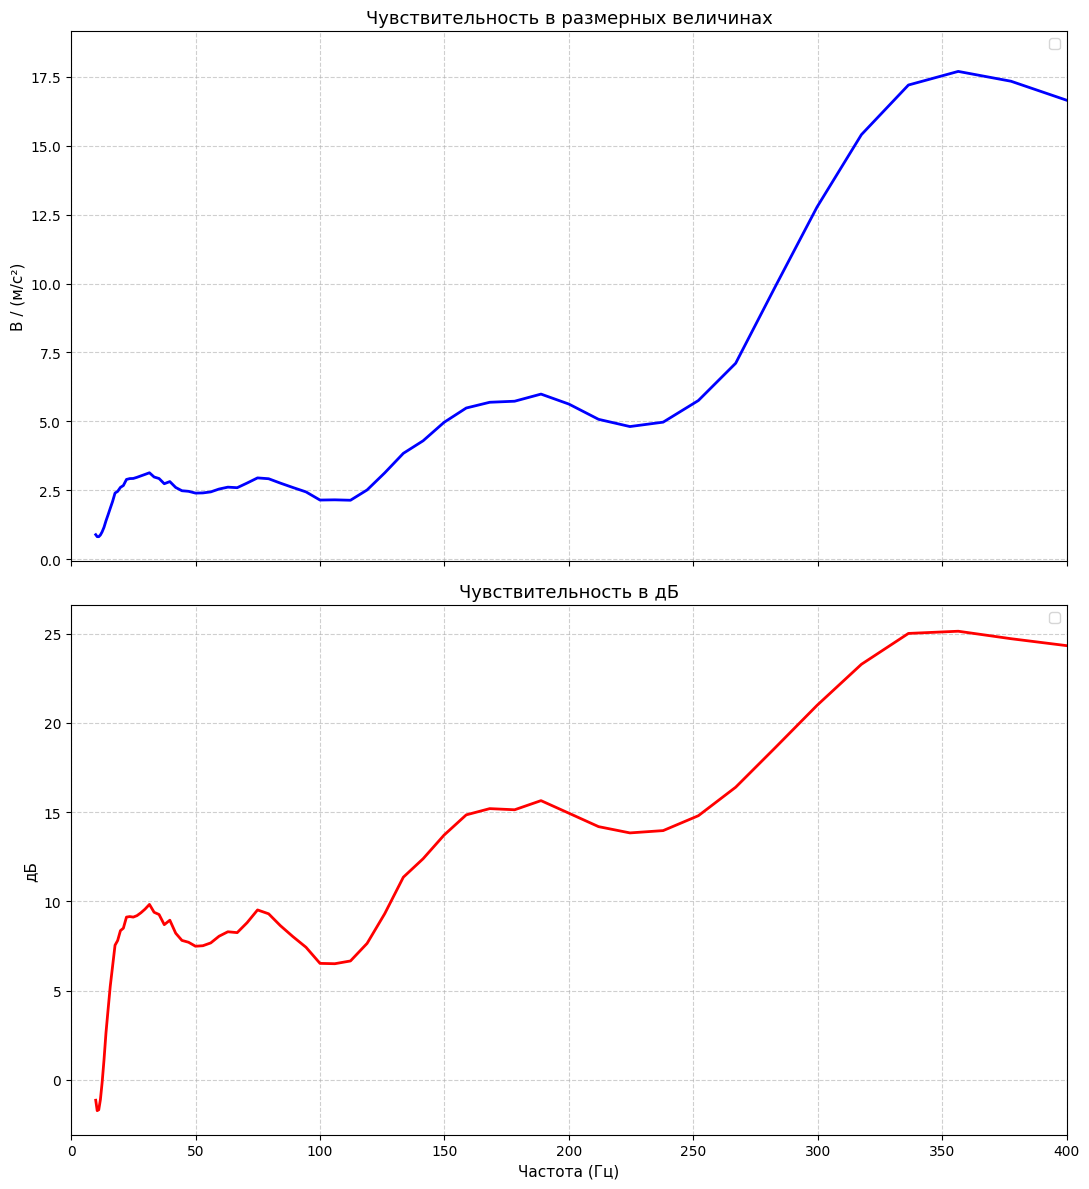

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch, savgol_filter

def get_octave_bands(f_min, f_max, fraction=12):
    f_ref = 100.0
    n_min = np.floor(fraction * np.log2(f_min / f_ref))
    n_max = np.ceil(fraction * np.log2(f_max / f_ref))
    n = np.arange(n_min, n_max + 1)
    
    f_center = f_ref * (2 ** (n / fraction))
    f_lower = f_center * (2 ** (-1 / (2 * fraction)))
    f_upper = f_center * (2 ** (1 / (2 * fraction)))
    return f_lower, f_center, f_upper

def run_calibration_smoothed(file_path, duration_min=1):
    fs, data = wavfile.read(file_path)
    
    if data.dtype == np.int16:
        data = data.astype(np.float64) / 32768.0
    elif data.dtype == np.int32:
        data = data.astype(np.float64) / 2147483648.0

    ref_accel = data[:, 0]
    rec_volts = data[:, 1]

    samples_per_min = int(fs * 60 * duration_min)
    num_segments = len(data) // samples_per_min
    
    f_low, f_mid, f_high = get_octave_bands(10, fs/2.5, fraction=12)
    
    total_p_ref = np.zeros(len(f_mid))
    total_p_rec = np.zeros(len(f_mid))

    for i in range(num_segments):
        start = i * samples_per_min
        end = start + samples_per_min
        
        f, p_ref = welch(ref_accel[start:end], fs, nperseg=fs*60, window='hann')
        _, p_rec = welch(rec_volts[start:end], fs, nperseg=fs*60, window='hann')
        
        for j in range(len(f_mid)):
            mask = (f >= f_low[j]) & (f < f_high[j])
            if np.any(mask):
                total_p_ref[j] += np.trapz(p_ref[mask], f[mask])
                total_p_rec[j] += np.trapz(p_rec[mask], f[mask])

    rms_ref = np.sqrt(total_p_ref / num_segments)
    rms_rec = np.sqrt(total_p_rec / num_segments)
    
    sens_linear = np.divide(rms_rec, rms_ref, out=np.zeros_like(rms_rec), where=rms_ref!=0)
    sens_db = 20 * np.log10(rms_rec + 1e-12) - 20 * np.log10(rms_ref + 1e-12)
    
    # --- СГЛАЖИВАНИЕ ---
    # window_length должен быть нечетным числом и меньше длины массива
    window = 11 if len(f_mid) > 11 else (len(f_mid) // 2 * 2 - 1)
    poly_order = 3 # Порядок полинома
    
    sens_lin_smooth = savgol_filter(sens_linear, window, poly_order)
    sens_db_smooth = savgol_filter(sens_db, window, poly_order)
    
    return f_mid, sens_linear, sens_lin_smooth, sens_db, sens_db_smooth

# --- Визуализация ---
try:
    freqs, s_lin, s_lin_s, s_db, s_db_s = run_calibration_smoothed('/Users/bogda/Desktop/Acoustics/Scientific/Исходные данные/Seismic/2804/20260429-082526(UTC)-Default setup-0080272085.wav')

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 12), sharex=True)

    # График 1: Линейная чувствительность
#    ax1.semilogx(freqs, s_lin, color='gray', alpha=0.3, label='Исходные данные')
    ax1.plot(freqs, s_lin_s, 'b', linewidth=2)
    ax1.set_ylabel('В / (м/с²)', fontsize=11)
    ax1.set_title('Чувствительность в размерных величинах', fontsize=13)
    ax1.grid(True, which="both", ls="--", alpha=0.6)
    ax1.set_xlim([0, 400])  # Ограничение по X от 20 Гц до 1000 Гц
    ax1.legend()

    # График 2: Чувствительность в дБ
#    ax2.semilogx(freqs, s_db, color='gray', alpha=0.3, label='Исходные данные')
    ax2.plot(freqs, s_db_s, 'r', linewidth=2)
    ax2.set_ylabel('дБ', fontsize=11)
    ax2.set_xlabel('Частота (Гц)', fontsize=11)
    ax2.set_title('Чувствительность в дБ', fontsize=13)
    ax2.grid(True, which="both", ls="--", alpha=0.6)
    ax2.set_xlim([0, 400])
    ax2.legend()

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Файл не найден.")